# Netflix_EDA_Visualization

**Exploratory Data Analysis & Visualization of Netflix Titles**

**Author:** Sabyasachi

Dataset: `netflix_titles.csv` (Kaggle Netflix Movies and TV Shows dataset)

### Questions I want to answer
1. How has Netflix's content library grown over time?
2. What's the split between Movies and TV Shows?
3. Which countries produce the most Netflix content?
4. What are the most common genres and ratings?
5. How long are Netflix movies typically, and how many seasons do TV shows usually have?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 1. Data structure & types

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (8807, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing values

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})[missing > 0]

,missing_count,missing_pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


**Observation:** `director`, `cast`, and `country` have the most missing values, "
"which makes sense — not every title has that metadata publicly listed. "
"`date_added`, `rating`, and `duration` have only a handful of missing values.

## 3. Duplicates

In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate titles:", df.duplicated(subset=['title']).sum())

Duplicate rows: 0
Duplicate titles: 0


## 4. Cleaning & feature engineering

In [6]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Split duration into a numeric value + unit (min for movies, seasons for TV shows)
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'([a-zA-Z]+)')

# Primary country (first listed) and primary genre (first listed)
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()
df['primary_genre'] = df['listed_in'].str.split(',').str[0].str.strip()

df[['date_added', 'year_added', 'duration_num', 'duration_unit', 'primary_country', 'primary_genre']].head()

,date_added,year_added,duration_num,duration_unit,primary_country,primary_genre
0,2021-09-25,2021.0,90.0,min,United States,Documentaries
1,2021-09-24,2021.0,2.0,Seasons,South Africa,International TV Shows
2,2021-09-24,2021.0,1.0,Season,NaN,Crime TV Shows
3,2021-09-24,2021.0,1.0,Season,NaN,Docuseries
4,2021-09-24,2021.0,2.0,Seasons,India,International TV Shows


## 5. Univariate analysis

### Movies vs TV Shows

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


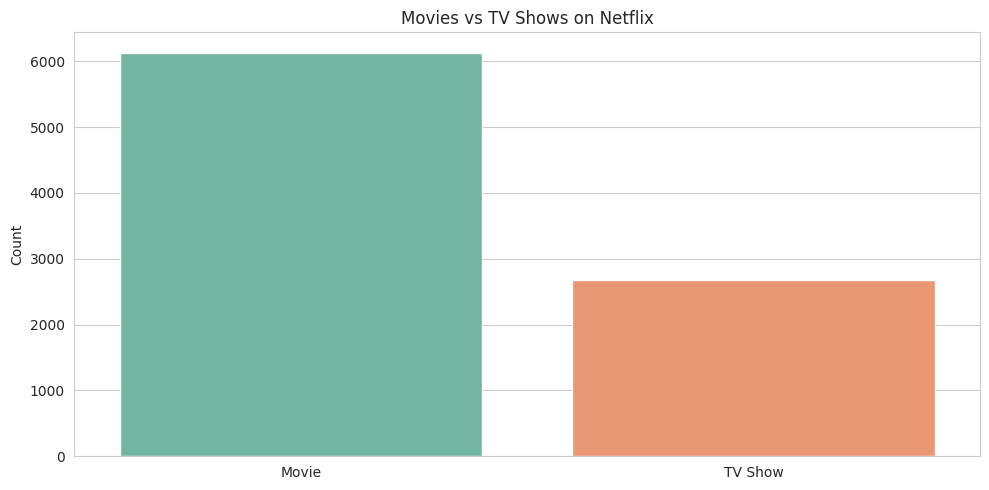

In [7]:
type_counts = df['type'].value_counts()
print(type_counts)

plt.figure()
sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("chart_type_split.png", dpi=120)
plt.show()

### Content added per year

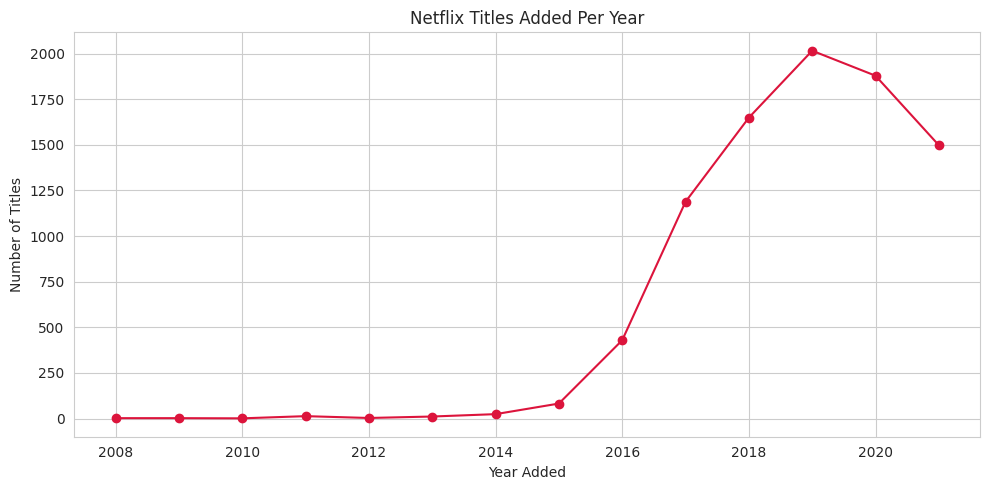

In [8]:
yearly = df['year_added'].value_counts().sort_index()

plt.figure()
yearly.plot(kind='line', marker='o', color='crimson')
plt.title("Netflix Titles Added Per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.savefig("chart_titles_per_year.png", dpi=120)
plt.show()

### Top 10 content-producing countries

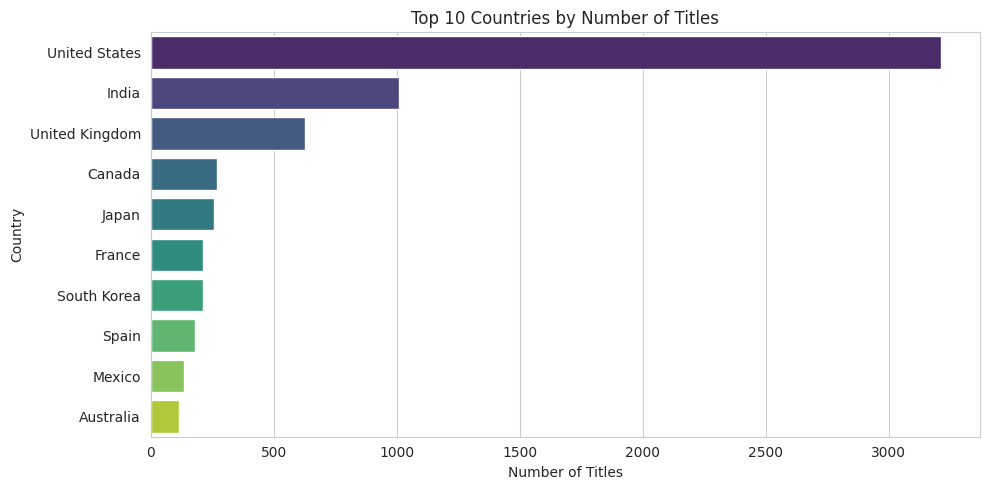

In [9]:
top_countries = df['primary_country'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis', legend=False)
plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("chart_top_countries.png", dpi=120)
plt.show()

### Top 10 genres

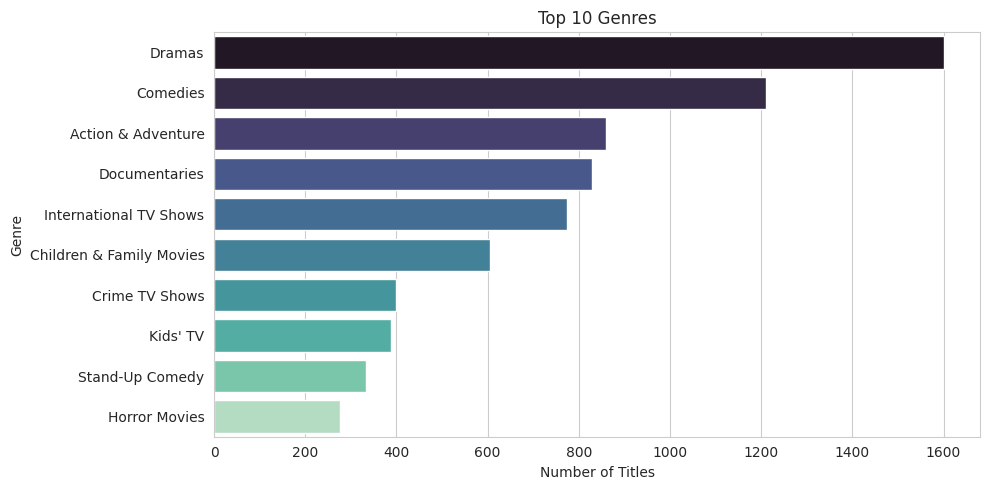

In [10]:
top_genres = df['primary_genre'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='mako', legend=False)
plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("chart_top_genres.png", dpi=120)
plt.show()

### Rating distribution

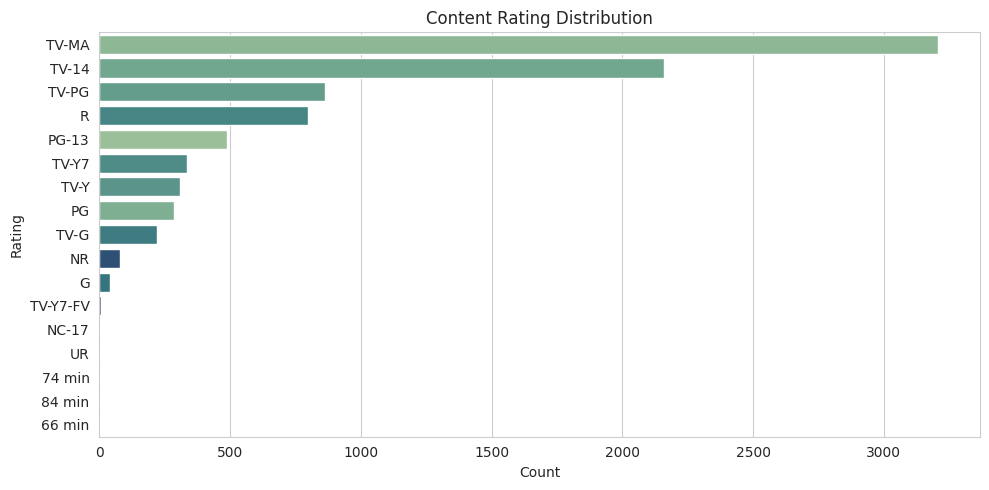

In [11]:
plt.figure()
order = df['rating'].value_counts().index
sns.countplot(data=df, y='rating', order=order, hue='rating', palette='crest', legend=False)
plt.title("Content Rating Distribution")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig("chart_ratings.png", dpi=120)
plt.show()

### Movie duration distribution

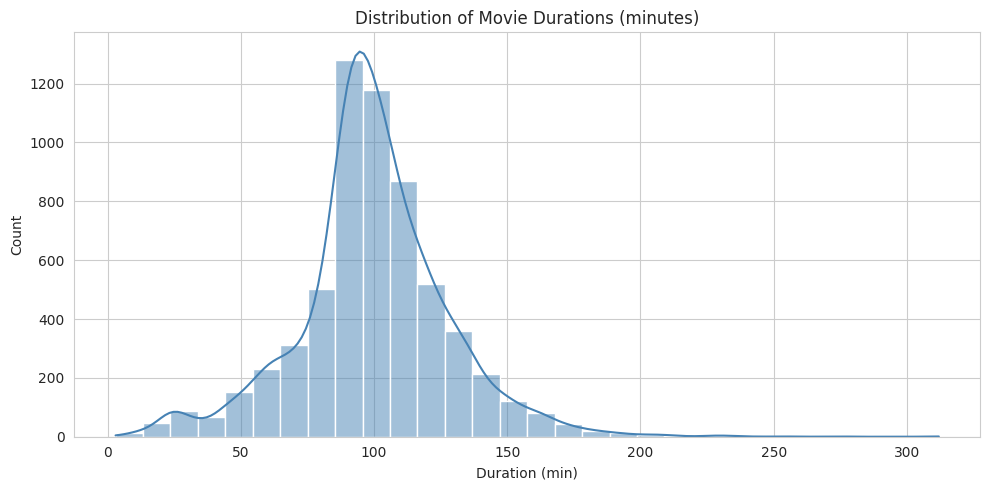

Average movie duration: 99.6 min
Median movie duration: 98.0 min


In [12]:
movies = df[df['type'] == 'Movie']

plt.figure()
sns.histplot(movies['duration_num'].dropna(), bins=30, kde=True, color='steelblue')
plt.title("Distribution of Movie Durations (minutes)")
plt.xlabel("Duration (min)")
plt.tight_layout()
plt.savefig("chart_movie_duration.png", dpi=120)
plt.show()

print("Average movie duration:", round(movies['duration_num'].mean(), 1), "min")
print("Median movie duration:", movies['duration_num'].median(), "min")

## 6. Bivariate analysis

### Movies vs TV Shows trend over time

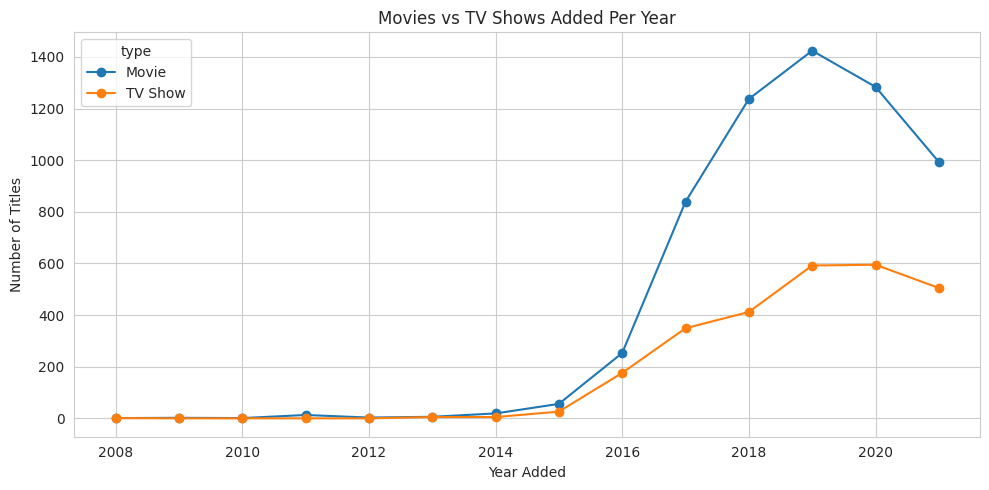

In [13]:
trend = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

plt.figure()
trend.plot(kind='line', marker='o', ax=plt.gca())
plt.title("Movies vs TV Shows Added Per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.savefig("chart_type_trend.png", dpi=120)
plt.show()

### Does the US dominate every genre, or does it vary by country?

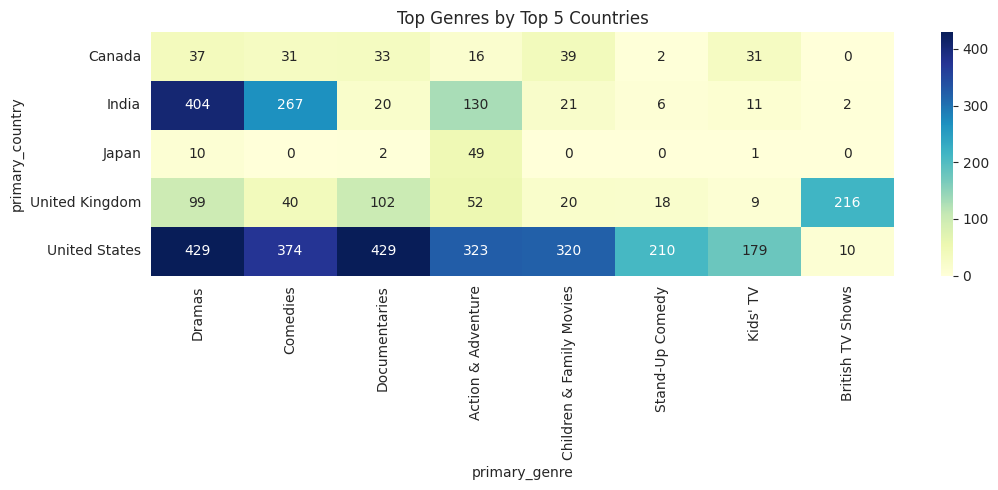

In [14]:
top5_countries = df['primary_country'].value_counts().head(5).index
subset = df[df['primary_country'].isin(top5_countries)]

genre_country = pd.crosstab(subset['primary_country'], subset['primary_genre'])
top_genre_cols = subset['primary_genre'].value_counts().head(8).index
genre_country = genre_country[top_genre_cols]

plt.figure(figsize=(11, 5))
sns.heatmap(genre_country, cmap='YlGnBu', annot=True, fmt='d')
plt.title("Top Genres by Top 5 Countries")
plt.tight_layout()
plt.savefig("chart_genre_country_heatmap.png", dpi=120)
plt.show()

## 7. Key findings

- The catalog is split roughly **70% Movies (6,131) vs 30% TV Shows (2,676)**.
- Content additions to Netflix **peaked in 2019**, after several years of rapid growth.
- The **United States (3,211 titles), India (1,008), and the United Kingdom (628)** are the top three content-producing countries.
- **Dramas** is the single most common primary genre (1,600 titles).
- The average movie runs **~100 minutes** (median 98 minutes).
- Most TV shows are short-lived: the average is under **2 seasons**.
- **TV-MA** is the most common content rating, suggesting the catalog skews toward mature audiences.
- No exact duplicate rows were found, but **`director` (29.9%) and `country` (9.4%) have meaningful missing data**, which should be kept in mind for any analysis that groups by those fields.
